In [ ]:
import torch
from math import ceil
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
import cv2
import random
import numpy as np
from definitions import (
    orientation_score_transform,
    cost_function,
    modulo,
    adaptive_sigmoid_norm,
    blob_filter
)


from PIL import Image
import torchvision.transforms as T
from torchvision.transforms import v2
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

torch.cuda.is_available()
shft = 0

# Definitions

Definition derivation ground truth

In [2]:
def rescale_gt(gt_contours, f):
    gt_rescale = []
    for c in gt_contours:    
        rescaled = c + torch.tensor(f.shape) /2
        gt_rescale.append(rescaled)
    return gt_rescale


In [3]:
def principal_orientation_torch(mask: torch.Tensor):
    # Get foreground coordinates
    ys, xs = torch.where(mask > 0)

    xs = xs.float()
    ys = ys.float()

    # Compute centroid
    x_mean = xs.mean()
    y_mean = ys.mean()

    # Centered coordinates
    x = xs - x_mean
    y = ys - y_mean

    # Second-order central moments
    mu20 = (x * x).mean()
    mu02 = (y * y).mean()
    mu11 = (x * y).mean()

    # Orientation formula
    angle_rad = 0.5 * torch.atan2(2 * mu11, mu20 - mu02)
    

    return angle_rad

In [4]:
def winding_number_mask(H, W, polygon):
    """
    Compute winding-number mask for an HxW grid given a polygon.
    
    polygon: (N, 2) tensor of xy vertices
    Returns: (H, W) tensor of winding numbers
    """
    device = polygon.device
    dtype  = polygon.dtype

    # Build grid directly inside the function
    xs = torch.linspace(0, W-1, W, device=device, dtype=dtype)
    ys = torch.linspace(0, H-1, H, device=device, dtype=dtype)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")  # (H, W)

    N = polygon.shape[0]
    p0 = polygon
    p1 = polygon.roll(-1, 0)

    y0, x0 = p0[:, 0], p0[:, 1]
    y1, x1 = p1[:, 0], p1[:, 1]

    # Expand grid to (N, H, W)
    X = grid_x.unsqueeze(0)
    Y = grid_y.unsqueeze(0)

    # Crossing tests
    cond_up   = (y0[:, None, None] <= Y) & (y1[:, None, None] >  Y)
    cond_down = (y0[:, None, None] >  Y) & (y1[:, None, None] <= Y)

    # is_left test
    is_left_val = (
        (x1 - x0)[:, None, None] * (Y - y0[:, None, None]) -
        (y1 - y0)[:, None, None] * (X - x0[:, None, None])
    )

    wn = (
        torch.sum(cond_up   & (is_left_val < 0), dim=0).int() -
        torch.sum(cond_down & (is_left_val > 0), dim=0).int()
    )

    return wn

Set Seed

In [5]:
def set_seed(seed: int = 42):
    # Python RNG
    random.seed(seed)

    # NumPy RNG
    np.random.seed(seed)

    # PyTorch RNG (CPU)
    torch.manual_seed(seed)

    # PyTorch RNG (all GPUs)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For PyTorch 2.x compilers
    #torch.use_deterministic_algorithms(True)

Clean data

In [6]:
def clean_data(os):
    pool = torch.nn.MaxPool2d(kernel_size=11, stride=1, padding=5)
    closing_data = -pool(-pool(os))

    pool = torch.nn.MaxPool2d(kernel_size=7, stride=1, padding=3)
    opening_data = pool(-pool(-closing_data)) 
    closing_data = -pool(-pool(opening_data))
    return  closing_data

# Import SEM image

In [8]:
data_folder = r"C:/Users/levis/OneDrive - ASML/Documents/2602_dEPE2_AlexDuarte/depe_sim_02"

set_seed(100)

# Split Data
imgs = list(Path(data_folder).iterdir())
imgs.sort()

In [9]:
hvsem_file="stack_hvsem.tiff"
hvsems = []

for idx in range(len(imgs)):
    hvsems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], hvsem_file))
    ))

lines_sem_file="lines_sem.tiff"
lines_sems = []

for idx in range(len(imgs)):
    lines_sems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], lines_sem_file))
    ))

holes_sem_file="holes_sem.tiff"
holes_sems = []

for idx in range(len(imgs)):
    holes_sems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], holes_sem_file))
    ))

Lines + Pillars

In [10]:
fs = (torch.cat(lines_sems, dim=0)+torch.cat(holes_sems, dim=0)).to("cuda") #torch.cat(hvsems, dim=0).to("cuda")
fs.shape
fs.device

device(type='cuda', index=0)

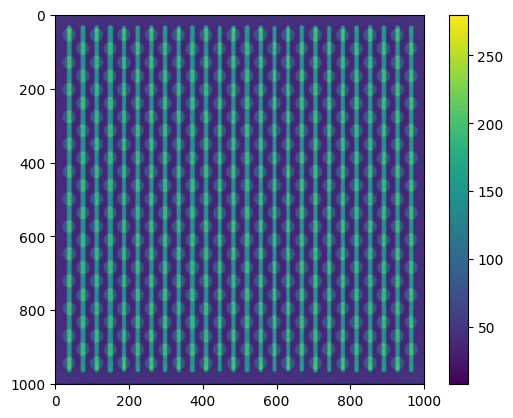

In [11]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(fs[0].cpu())
fig.colorbar(cbar, ax=ax)

### Shift Pillars

In [12]:
fs = (torch.cat(lines_sems, dim=0) + torch.roll(torch.cat(holes_sems, dim=0), shifts = shft, dims=-1)).to("cuda") #torch.cat(hvsems, dim=0).to("cuda")
fs.shape
fs.device

device(type='cuda', index=0)

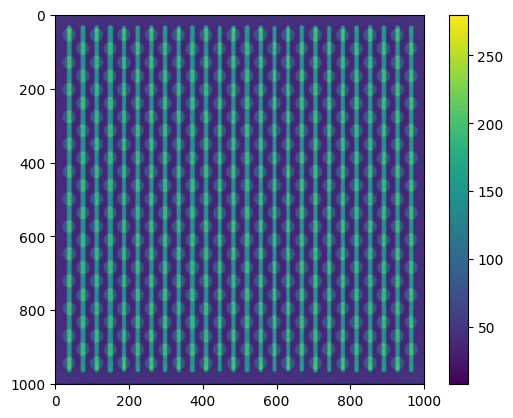

In [13]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(fs[0].cpu())
fig.colorbar(cbar, ax=ax)

## Ground truth segmentation of SEM image

### Import ground truth

In [14]:
No = 12;

In [15]:
h, w = fs[0].shape

top_sems = []
bottom_sems = []

for idx in range(len(imgs)):
    top_contours = np.load(Path.joinpath(imgs[idx], "lines.npz"))
    bottom_contours = np.load(Path.joinpath(imgs[idx], "holes.npz"))

    # create top_sem binary image
    top_cont = [top_contours[f] + w / 2 for f in top_contours.files]    

    top_sem_percomp = []

    for c in top_cont:
        top_sem = np.zeros((w, h), dtype=np.int8)

        c = np.vstack((c, c[0]))
        c = np.array(c).reshape((-1, 1, 2)).astype(np.int32)
        cv2.drawContours(top_sem, [c], -1, 1, -1) #-1 means thickness --> fills the shape
        _out_cnt = np.zeros((w, h), dtype=np.int8)
        cv2.drawContours(_out_cnt, [c], -1, 1, 1)
        # top_sem -= _out_cnt  # exclude contours line
        top_sem_percomp.append(torch.tensor(top_sem))

    #top_sems.append(torch.from_numpy(top_sem)[torch.newaxis, :])
    top_sems.append(top_sem_percomp)

    # create bottom_sem binary image
    bottom_cont = [bottom_contours[f] + w / 2 for f in bottom_contours.files]
    bottom_sem = np.zeros((w, h), dtype=np.int8)   
    

    for c in bottom_cont:
        c = np.vstack((c, c[0]))
        c = np.array(c).reshape((-1, 1, 2)).astype(np.int32)
        cv2.drawContours(bottom_sem, [c], -1, 1, -1)
        _out_cnt = np.zeros((w, h), dtype=np.int8)
        cv2.drawContours(_out_cnt, [c], -1, 1, 1)
        # bottom_sem -= _out_cnt  # exclude contours line
        
                    
    bottom_sems.append(torch.from_numpy(bottom_sem)[torch.newaxis, :])
    

bottom_sems = torch.cat(bottom_sems, dim=0).to("cuda")


### Define Ground truth lift

In [16]:
gt_angles = [[modulo(torch.round(principal_orientation_torch(i)*(No/ (2*torch.pi))), No).int() for i in top_sems[j]] for j in range(len(top_sems))]

In [17]:
gt_connected_comp = torch.zeros(fs.shape[-3],No, fs.shape[-2], fs.shape[-1])
for i in range(len(fs)):
    for j in range(len(gt_angles[i])):
        gt_connected_comp[i][gt_angles[i][j]]=torch.max(gt_connected_comp[i][gt_angles[i][j]],top_sems[i][j])
        gt_angles_p = modulo(gt_angles[i][j] + No/2, No).int()
        gt_connected_comp[i][gt_angles_p]=torch.max(gt_connected_comp[i][gt_angles[i][j]],top_sems[i][j])

gt_connected_comp = gt_connected_comp.to(fs.device)



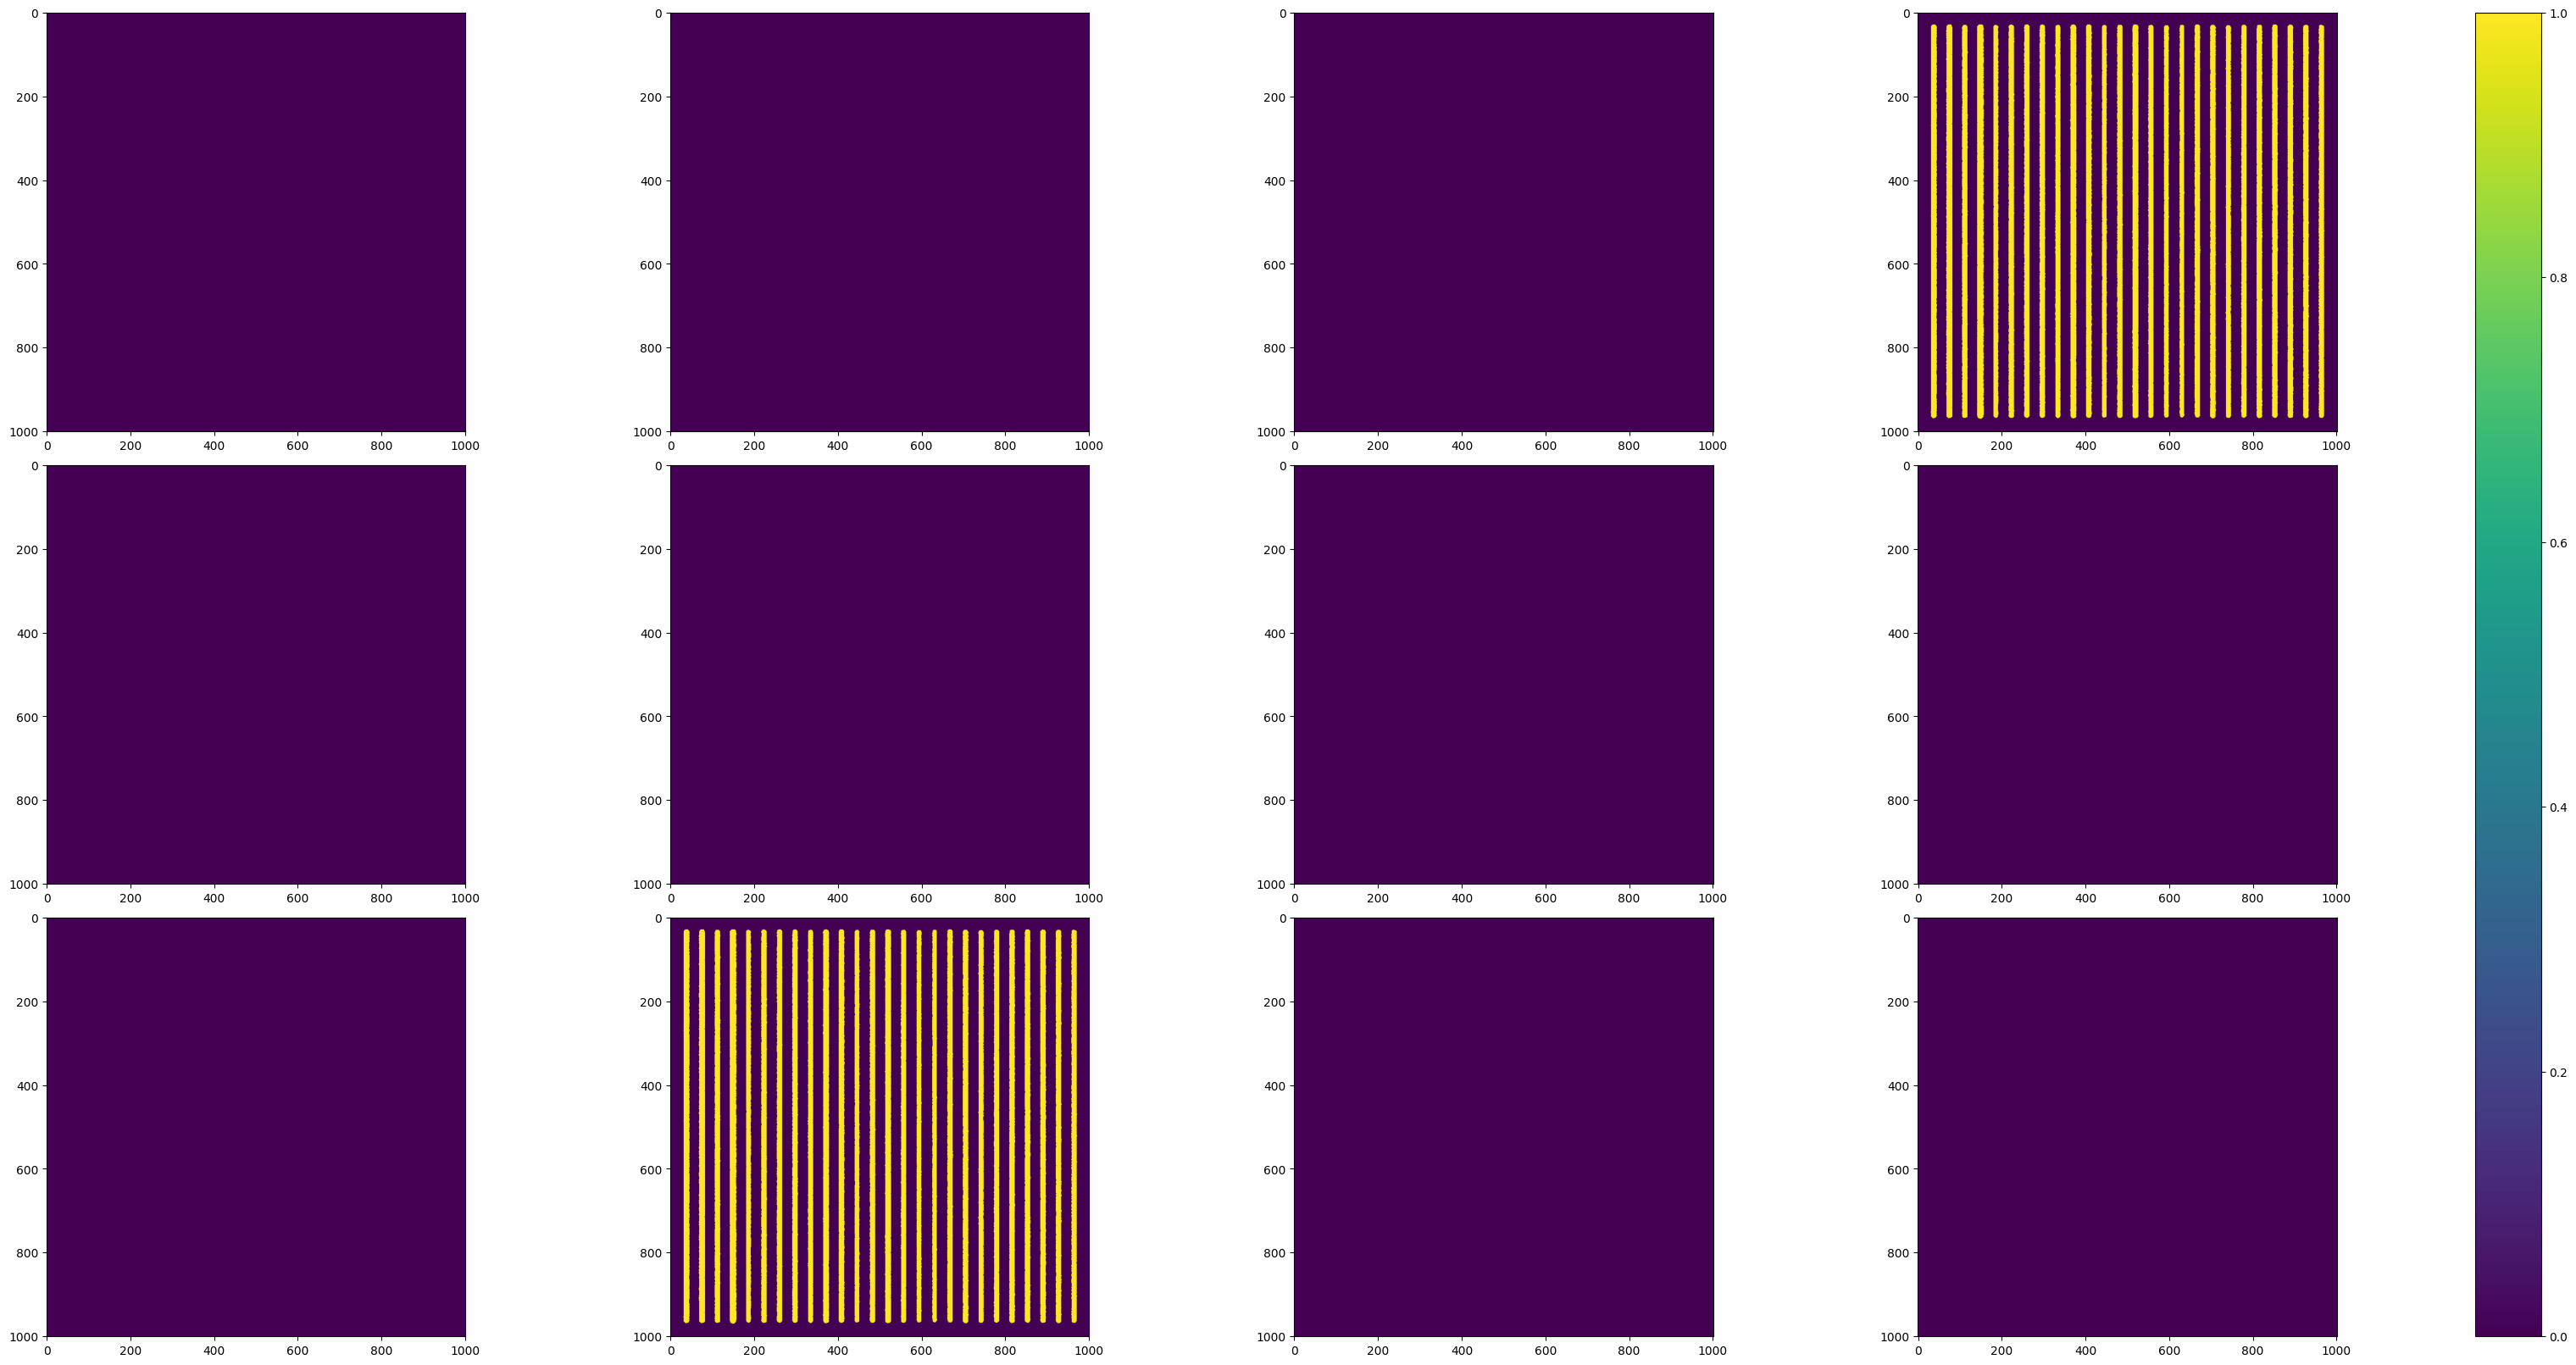

In [18]:
vmin = gt_connected_comp[0].min()
vmax = gt_connected_comp[0].max()

fig, ax = plt.subplots(ceil(gt_connected_comp[0].shape[0]/4), 4, figsize=(8 * 4, 4 * 4), layout="constrained")

ims = []
for i in range(ceil(gt_connected_comp[0].shape[0]/4)):
    for j in range(4):
        im = ax[i, j].imshow(gt_connected_comp[0][i * 4 + j, :, :].cpu(), vmin=vmin, vmax=vmax,
                        cmap="viridis",
                        aspect="equal")
        ims.append(im)

fig.colorbar(ims[0], ax=ax, location="right");

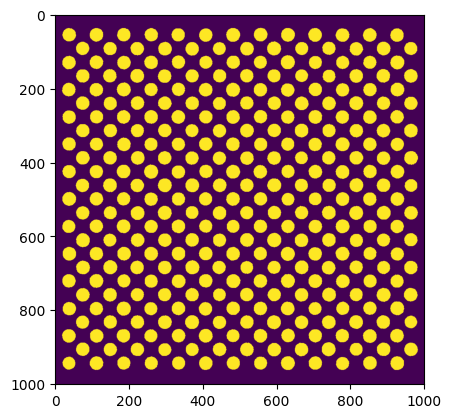

In [19]:
plt.imshow(bottom_sems[0].cpu())

## Reshape data set

In [20]:
# fs is a tensor of shape [N, 1, 1001, 1001] (N images, 1 channel --> grayscale)
# Step 1: Crop to 1000x1000, so that it is divisible by 200
fs_cropped = fs[:, :1000, :1000]
lifts_cropped = gt_connected_comp[:, :1000, :1000]
bottom_sems_cropped = bottom_sems[:, :1000, :1000]

# Stap 2: Unfold 
fs_tiles = fs_cropped.unfold(-2, 200, 200).unfold(-2, 200, 200)
bottom_sems_tiles = bottom_sems_cropped.unfold(-2, 200, 200).unfold(-2, 200, 200)
# the shape is now: [N, 5, 5, 200, 200]
lifts_tiles = lifts_cropped.unfold(-2, 200, 200).unfold(-2, 200, 200)
# De shape is npw: [N, No, 5, 5, 200, 200]


# Step 3: Reorganise to [N*25, 200, 200]
fs_tiles = fs_tiles.contiguous().view(-1, 200, 200)
bottom_sems_tiles = bottom_sems_tiles.contiguous().view(-1, 200, 200)
lifts_tiles = lifts_tiles.permute(0, 2, 3, 1, 4, 5).contiguous().view(-1, No, 200, 200)

print(f"Old shape: {fs.shape}")
print(f"New shape: {fs_tiles.shape}") # this will be [N*25, No, 200, 200] 

print(f"Old shape: {gt_connected_comp.shape}")
print(f"New shape: {lifts_tiles.shape}") # this will be [N*25, No, 200, 200] 

print(f"Old shape: {bottom_sems.shape}")
print(f"New shape: {bottom_sems_tiles.shape}") # this will be [N*25, No, 200, 200] 

Old shape: torch.Size([20, 1001, 1001])
New shape: torch.Size([500, 200, 200])
Old shape: torch.Size([20, 12, 1001, 1001])
New shape: torch.Size([500, 12, 200, 200])
Old shape: torch.Size([20, 1001, 1001])
New shape: torch.Size([500, 200, 200])


## Experimental dataset

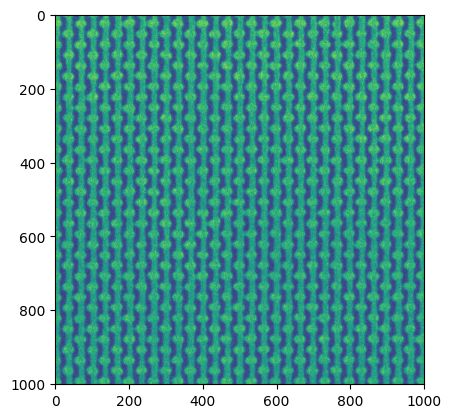

In [21]:
#D23_mod11_CPO1_nominal_uncorrected_image-36-1-0-11-0-Channel--2147483648-before.bmp without mistake_, with mistake _2
#D23_mod11_CPO1_offset1_uncorrected_image-37-1-0-11-0-Channel--2147483648-before.bmp _4
#D23_mod11_CPO1_offset2_uncorrected_image-38-1-0-11-0-Channel--2147483648-before.bmp _5
#D23_mod11_CPO1_offset3_uncorrected_image-39-1-0-11-0-Channel--2147483648-before.bmp _6
#D23_mod11_CPO1_maxoffset_uncorrected_image-40-1-0-11-0-Channel--2147483648-before.bmp _3

index = 6

test = v2.functional.pil_to_tensor(
    Image.open("C:/Users/levis/OneDrive - ASML/Documents/2025_Orion_MEM/D23_mod11_CPO1_offset3_uncorrected_image-39-1-0-11-0-Channel--2147483648-before.bmp")   
    ).to("cuda")

plt.imshow(test[:,200:1201,1000:2001][0].cpu())

# Identify Line-Like Structures

## Learn parameters of line-ness filter

### loss function
    

In [22]:
def dice_loss(input, target, smooth=1e-10):
    """
    Continuous DICE coefficient suitable for use as a loss function for binary segmentation, calculated as:
    $$
        1 - \\frac{2*(input*target).sum()+smooth}{input.sum()+target.sum()+smooth}
    $$

    Parameters
    ------------
    input: torch.Tensor
    Tensor of any shape with scalar elements in the range [0,1].

    target: torch.Tensor
    Label tensor with the same shape as the input with elements in the set {0,1}.

    smooth: float
    Smoothing factor that is added to both the numerator and denominator to avoid divide-by-zero.

    """
    AinterB = (input.view(-1) * target.view(-1)).sum()
    A = input.view(-1).sum()
    B = target.view(-1).sum()
    dice = (2 * AinterB + smooth) / (A + B + smooth)
    return 1 - dice


In [23]:
def tversky_loss(input, target, alpha=0.5, beta=0.5, eps=1e-6):
    TP = (input * target).sum(dim=(-3,-2,-1))
    FP = (input * (1 - target)).sum(dim=(-3,-2,-1))
    FN = ((1 - input) * target).sum(dim=(-3,-2,-1))

    denom = TP + alpha * FP + beta * FN + eps

    tversky_index = (TP + eps) / denom
    loss = 1 - tversky_index

    # Return mean batch loss
    return loss.mean()


In [24]:
def sparseθ_loss(input, p): # B, Or, H, W
    lp = ((torch.abs(input)**p).sum(dim=(-3))**(1.0 / p))/(input.shape[-3]** (1.0 / p))  # shape: B, H W  
    # Return mean batch loss
    return lp.mean()

### the model

In [25]:
def model(f, σs , σa, λ, p, t, scale):
    No = 12
    os = orientation_score_transform(f, No, 0.9)
    
    os_norm = adaptive_sigmoid_norm(os.real, scale)
    images = os_norm.sum(dim=-3)    
    os = orientation_score_transform(images, No, 0.9)        
    
    cost = cost_function(os.real, σs, σa, λ, p)
    
    eps = 1e-3      # controls sharpness
    bin = torch.sigmoid((t - cost) / eps) # we use t - cost to invert the output, i.e. 0 --> 1 and 1 --> 0
                        
    return bin

In [26]:
log_σs = torch.tensor(0., requires_grad=True) 
log_σa = torch.tensor(0., requires_grad=True)
sqrt_λ_norm = torch.tensor(1., requires_grad=True)
sqrt_p = torch.tensor(0., requires_grad=True)
t = torch.tensor(0.,  device=fs.device, requires_grad=True)
log_scale = torch.zeros(12, device="cuda", requires_grad=True)


parameters = [log_σs, log_σa, sqrt_λ_norm, sqrt_p , t , log_scale] 
optimizer = torch.optim.AdamW(parameters, lr=0.05)
# optimizer = torch.optim.SGD(parameters, lr=0.0001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9) #0.99

batch_size = 4
dataset = TensorDataset(fs_tiles[:17*25], lifts_tiles[:17*25]) #1
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 500 steps of gradient descent with the whole dataset
losses = []
num_epochs = 10 #100

with tqdm(range(num_epochs)) as pbar:
    for epoch in pbar:
        epoch_loss = 0
        
        for batch_fs, batch_lifts in data_loader:
            optimizer.zero_grad() # set x.grad = 0 for all relevant tensors x

            σs = torch.exp(log_σs) #.clamp(-10,10)
            σa = torch.exp(log_σa) 
            λ_norm = sqrt_λ_norm**2
            p = torch.log(1 + torch.exp(sqrt_p)) + 1 #torch.exp(log_p)
            scale = torch.exp(log_scale)            
            
            bin = model(batch_fs,  σs , σa , 100. * λ_norm, p, torch.sigmoid(t), scale[None,:,None,None]) 
                
            loss = tversky_loss(bin, batch_lifts, alpha=0.5, beta=0.5) #+ sparseθ_loss(bin, 1.)

            if torch.isnan(loss):
                print("Loss is NaN")
                break
                    
            loss.backward()# x.grad += (pd loss)/(pd x) for all relevant tensors x

            #torch.nn.utils.clip_grad_norm_(parameters, max_norm=1.0)

            optimizer.step()
            epoch_loss += loss.item()
            #torch.nn.utils.clip_grad_norm_(parameters, 1.0)
            
        scheduler.step()
        
        
        # average loss 
        avg_loss = epoch_loss / len(data_loader)
        losses.append(avg_loss)

        pbar.set_postfix(loss=avg_loss)


fig, ax = plt.subplots(1, 1)
ax.plot(losses)
ax.loglog();

 20%|██        | 2/10 [00:52<03:28, 26.12s/it, loss=0.113]


KeyboardInterrupt: 

In [ ]:
torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1, torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]

In [ ]:
# save_dict = {
#     "log_σs": log_σs.detach(),
#     "log_σa": log_σa.detach(),
#     "sqrt_λ_norm": sqrt_λ_norm.detach(),
#     "sqrt_p": sqrt_p.detach(),
#     "t": t.detach(),
#     "log_scale": log_scale.detach(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "scheduler_state_dict": scheduler.state_dict(),
#     "losses": losses,
# }
# 
# torch.save(save_dict, "model_parameters_CC_lines.pth")


In [27]:
saved_parameters = torch.load("model_parameters_CC_lines.pth")
log_σs = saved_parameters["log_σs"]
log_σa = saved_parameters["log_σa"]
sqrt_λ_norm = saved_parameters["sqrt_λ_norm"]
sqrt_p = saved_parameters["sqrt_p"]
t = saved_parameters["t"]
log_scale = saved_parameters["log_scale"]

test images from SYNTHETIC dataset

In [28]:
with torch.no_grad():
    components= model(fs[-3:], torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1 , torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()

components = torch.stack([clean_data(image) for image in components])

#torch.save(components, f"lines.pt") #shift_{shft}
 

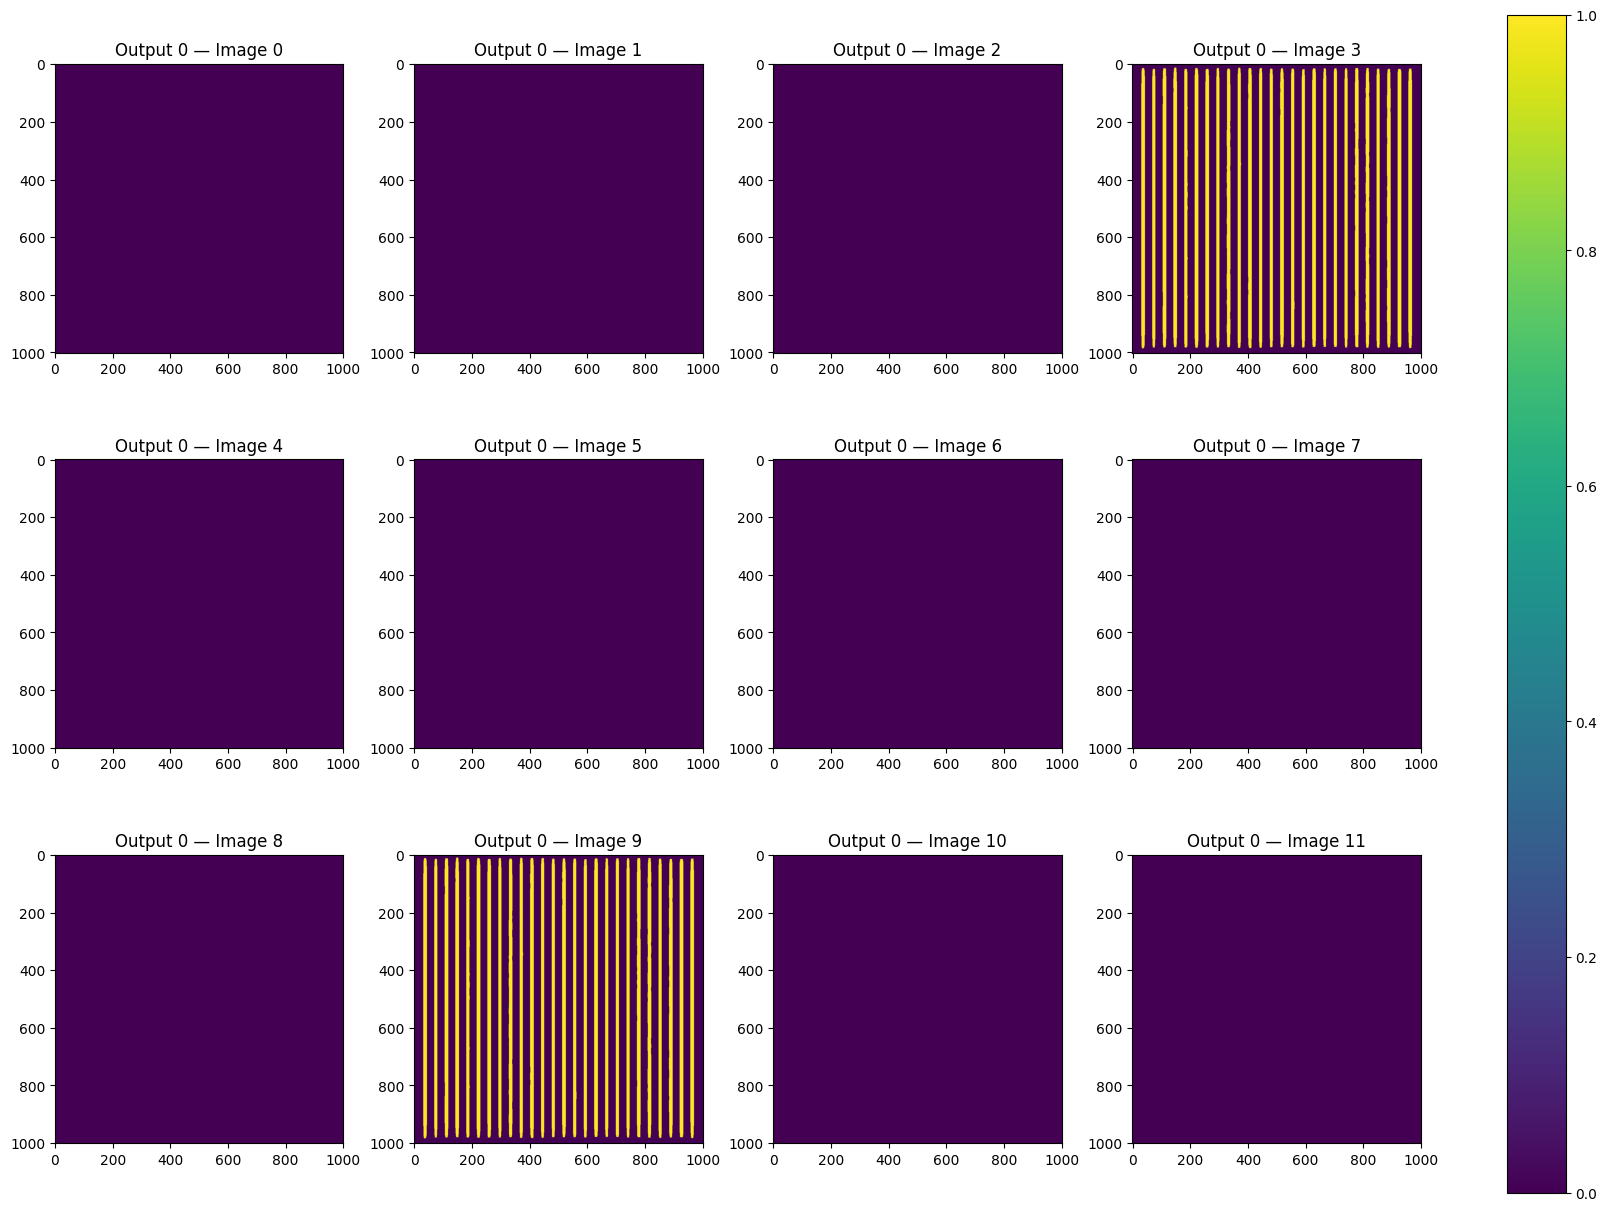

In [29]:
output = components[0][None]

for k in range(output.shape[0]):           # loop 12 times
    imgs = output[k]                      # shape: (12, H, W)
    n_imgs = imgs.shape[0]
    n_cols = 4
    n_rows = ceil(n_imgs / n_cols)

    vmin, vmax = 0, 1

    fig, ax = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        layout="constrained"
    )

    ax = ax.reshape(n_rows, n_cols)

    ims = []
    idx = 0

    for i in range(n_rows):
        for j in range(n_cols):
            if idx < n_imgs:
                im = ax[i, j].imshow(
                    imgs[idx],
                    vmin=vmin, vmax=vmax,
                    cmap="viridis",
                    aspect="equal"
                )
                ims.append(im)
                ax[i, j].set_title(f"Output {k} — Image {idx}")
            else:
                ax[i, j].axis("off")

            idx += 1

    fig.colorbar(ims[0], ax=ax, location="right")
    plt.show()



test images from EXPERIMENTAL data set

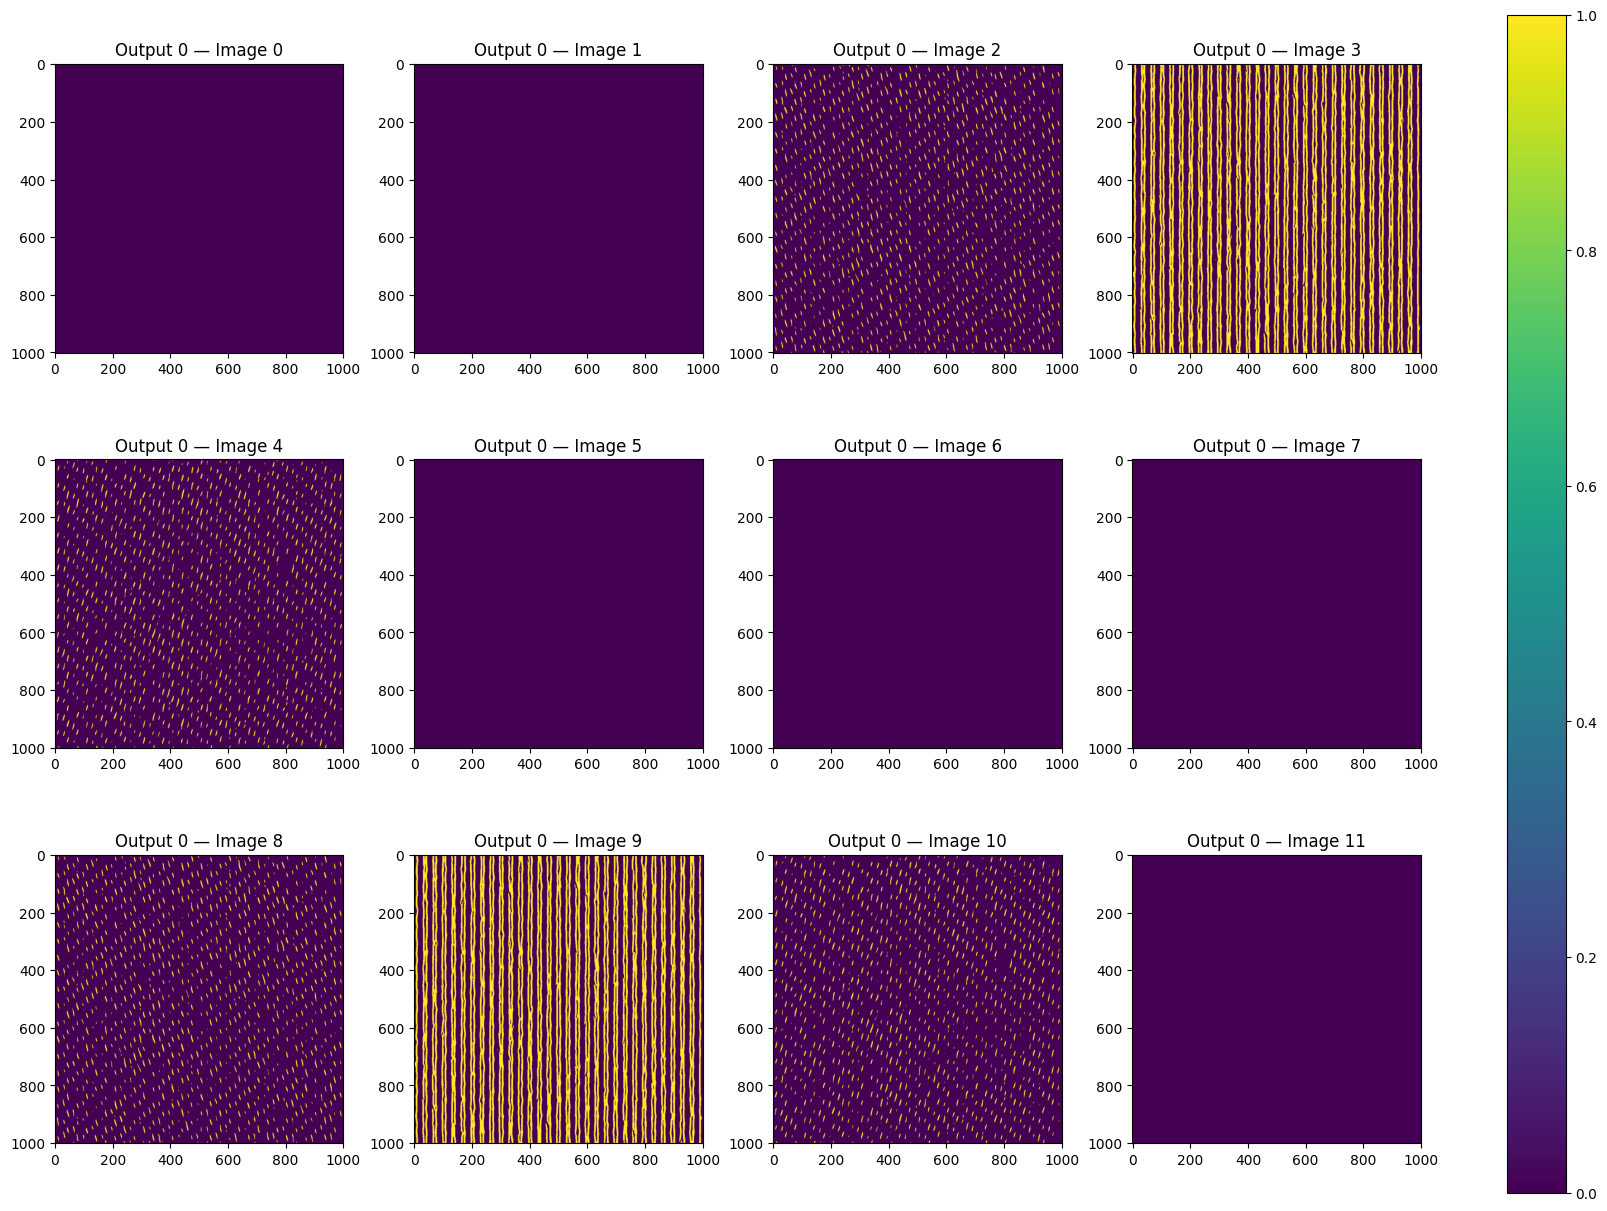

In [30]:
with torch.no_grad():
    lines_test= model(test[:,200:1201,1000:2001],torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1, torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()
    
for k in range(lines_test.shape[0]):           # loop 12 times
    imgs = lines_test[k]                      # shape: (12, H, W)
    n_imgs = imgs.shape[0]
    n_cols = 4
    n_rows = ceil(n_imgs / n_cols)

    vmin, vmax = 0, 1

    fig, ax = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        layout="constrained"
    )

    ax = ax.reshape(n_rows, n_cols)

    ims = []

    idx = 0

    for i in range(n_rows):
        for j in range(n_cols):
            if idx < n_imgs:
                im = ax[i, j].imshow(
                    imgs[idx],
                    vmin=vmin, vmax=vmax,
                    cmap="viridis",
                    aspect="equal"
                )
                ims.append(im)
                ax[i, j].set_title(f"Output {k} — Image {idx}")
            else:
                ax[i, j].axis("off")

            idx += 1

    fig.colorbar(ims[0], ax=ax, location="right")
    plt.show()


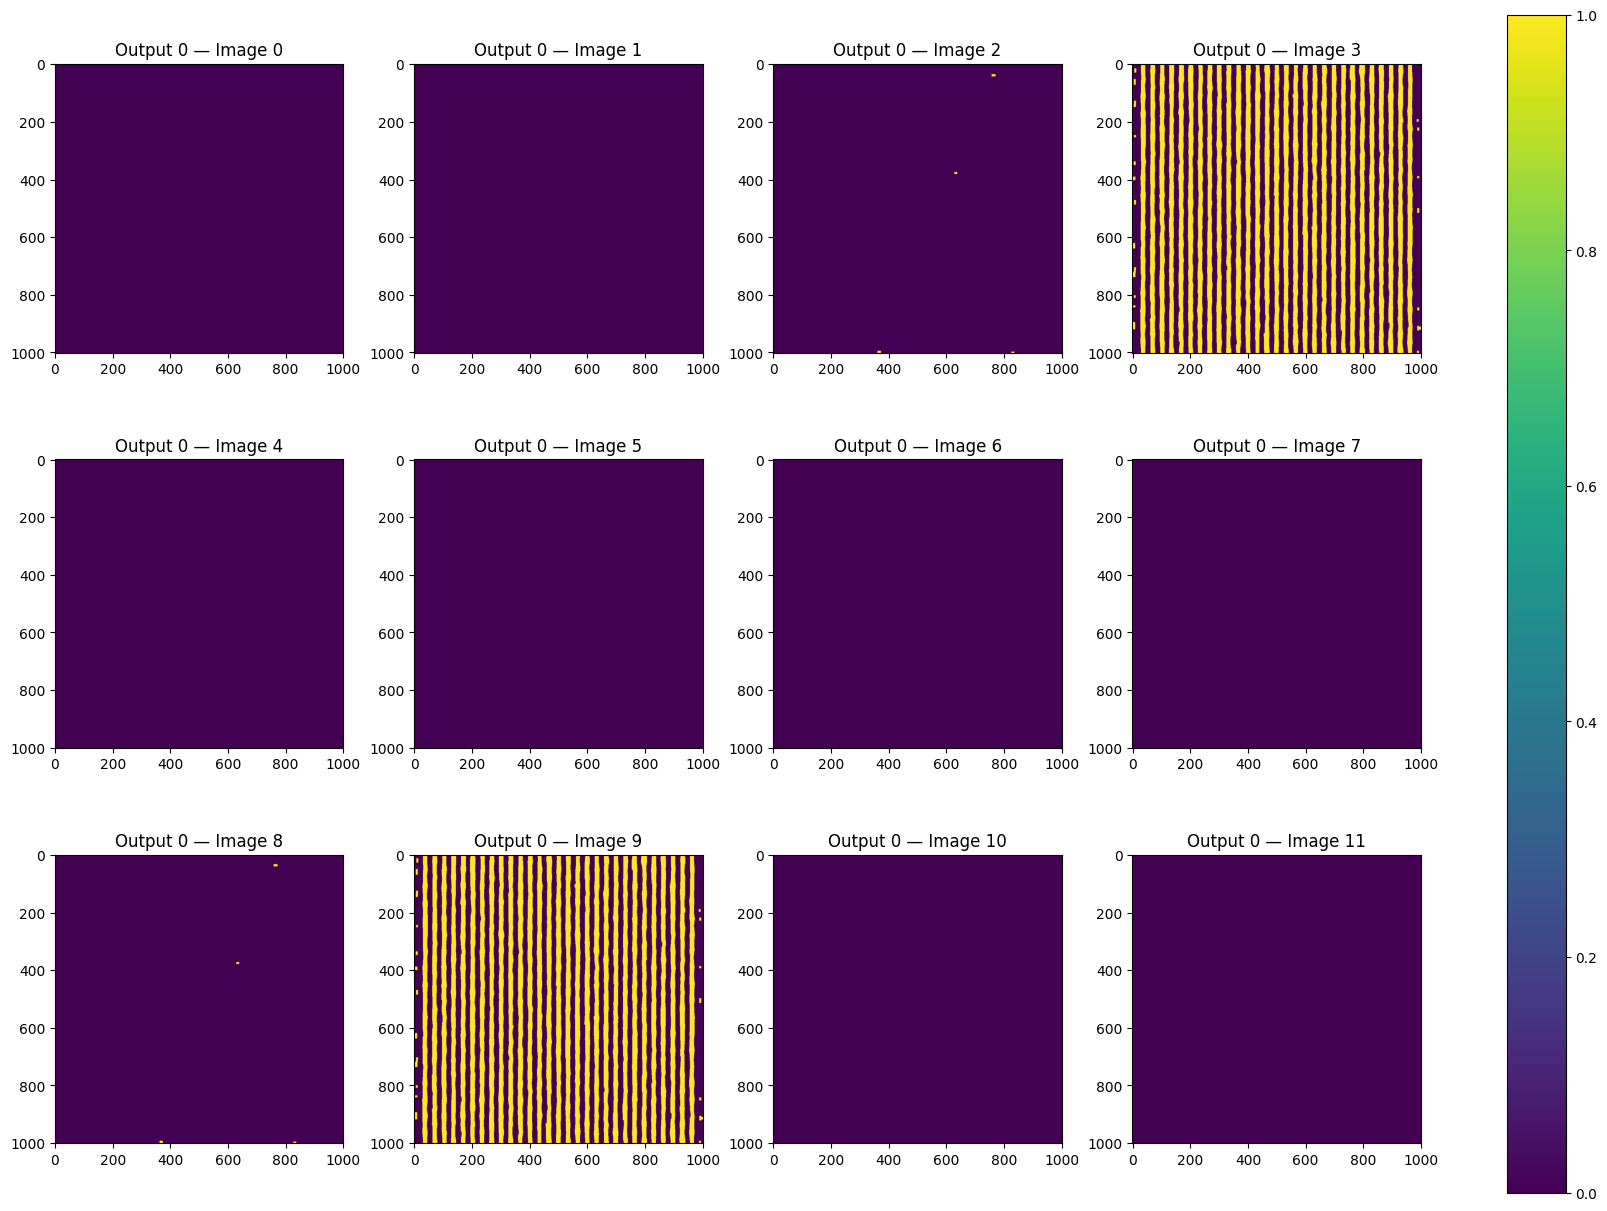

In [31]:
lines_cleaned = clean_data(lines_test) #on_opened[None]

for k in range(lines_test.shape[0]):           # loop 12 times
    imgs = lines_cleaned[k]                      # shape: (12, H, W)
    n_imgs = imgs.shape[0]
    n_cols = 4
    n_rows = ceil(n_imgs / n_cols)

    vmin, vmax = 0, 1

    fig, ax = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        layout="constrained"
    )

    ax = ax.reshape(n_rows, n_cols)

    ims = []
    idx = 0

    for i in range(n_rows):
        for j in range(n_cols):
            if idx < n_imgs:
                im = ax[i, j].imshow(
                    imgs[idx] > 0.8,
                    vmin=vmin, vmax=vmax,
                    cmap="viridis",
                    aspect="equal"
                )
                ims.append(im)
                ax[i, j].set_title(f"Output {k} — Image {idx}")
            else:
                ax[i, j].axis("off")

            idx += 1

    fig.colorbar(ims[0], ax=ax, location="right")
    plt.show()

In [32]:
#torch.save(lines_cleaned, f"lines_test_{index}.pt")

# Identify Blob-like structures

# Learn parameters of blob-filter

## the model

In [33]:
def model_blob(f, σs, λ , p , t, scale):
    No = 12
    os = orientation_score_transform(f, No, 0.9)
    os_norm = adaptive_sigmoid_norm(os.real, scale)
     
    images = os_norm.sum(dim=-3)
    
    blobs = blob_filter(images[:, None], σs).squeeze(-3) 
    
    cost = 1/(1 + λ *(blobs)**p) 

    eps = 1e-3
    bin = torch.sigmoid((t - cost) / eps) 

    return bin

In [34]:
log_σs = torch.tensor(0., device="cuda", requires_grad=True) 
sqrt_λ_norm = torch.tensor(1., device="cuda", requires_grad=True)
sqrt_p = torch.tensor(0., device="cuda", requires_grad=True)
t = torch.tensor(0., device="cuda", requires_grad=True)
log_scale = torch.zeros(12, device="cuda", requires_grad=True)


parameters = [log_σs, sqrt_λ_norm, sqrt_p, t, log_scale] 
optimizer = torch.optim.AdamW(parameters, lr=0.05)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999) #0.9

batch_size = 4
dataset = TensorDataset(fs_tiles[: 1*25], bottom_sems_tiles[: 1*25])
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


losses = []

num_epochs = 100 #10

for epoch in range(num_epochs):
    epoch_loss = 0
    
    for batch_fs, batch_bottom_sems in data_loader:
        optimizer.zero_grad() # set x.grad = 0 for all relevant tensors x  

        σs = torch.exp(log_σs) #.clamp(-10, 10)
        scale = torch.exp(log_scale) #.clamp(-10, 10)
        λ_norm = sqrt_λ_norm**2
        p = torch.log(1 + torch.exp(sqrt_p)) + 1
             
        blobs = model_blob(batch_fs, σs, 100. * λ_norm, p, torch.sigmoid(t), scale[None,:,None,None]) 
        loss = tversky_loss(blobs, batch_bottom_sems, alpha = 0.5, beta = 0.5)
                                       
        if torch.isnan(loss):
            print("Loss is NaN")
            break
             
        loss.backward() # x.grad += (pd loss)/(pd x) for all relevant tensors x
        
        #torch.nn.utils.clip_grad_norm_(log_scale, max_norm=0.0001)
        
        optimizer.step()
       
        epoch_loss += loss.item()
    
    
    scheduler.step()
    
    
    # average loss 
    avg_loss = epoch_loss / len(data_loader)
    losses.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")


fig, ax = plt.subplots(1, 1)
ax.plot(losses)
ax.loglog();


Epoch 0: Avg Loss = 0.8153
Epoch 10: Avg Loss = 0.2053
Epoch 20: Avg Loss = 0.1765
Epoch 30: Avg Loss = 0.1430


KeyboardInterrupt: 

In [ ]:
torch.exp(log_σs), 100. * sqrt_λ_norm**2, torch.log(1 + torch.exp(sqrt_p)) + 1, torch.sigmoid(t), torch.exp(log_scale)

In [ ]:
# save_dict = {
#     "log_σs": log_σs.detach(),
#     "sqrt_λ_norm": sqrt_λ_norm.detach(),
#     "sqrt_p": sqrt_p.detach(),
#     "t": t.detach(),
#     "log_scale": log_scale.detach(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "scheduler_state_dict": scheduler.state_dict(),
#     "losses": losses,
# }

# torch.save(save_dict, "model_parameters_CC_blobs.pth")

In [35]:
saved_parameters = torch.load("model_parameters_CC_blobs.pth")
log_σs = saved_parameters["log_σs"]
sqrt_λ_norm = saved_parameters["sqrt_λ_norm"]
sqrt_p = saved_parameters["sqrt_p"]
t = saved_parameters["t"]
log_scale = saved_parameters["log_scale"]

test with SYNTHETIC data set

In [36]:
with torch.no_grad():
    components_blobs = model_blob(fs[-3:], torch.exp(log_σs), 100. * sqrt_λ_norm**2,  torch.log(1 + torch.exp(sqrt_p)) + 1, torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()


components_blobs = torch.stack([clean_data(image[None])[0] for image in components_blobs])

#torch.save(components_blobs, f"blobs.pt") #shift_{shft}

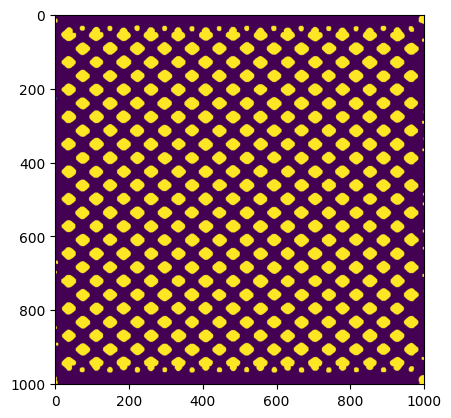

In [37]:
plt.imshow(components_blobs[1])


test with EXPERIMENTAL data set

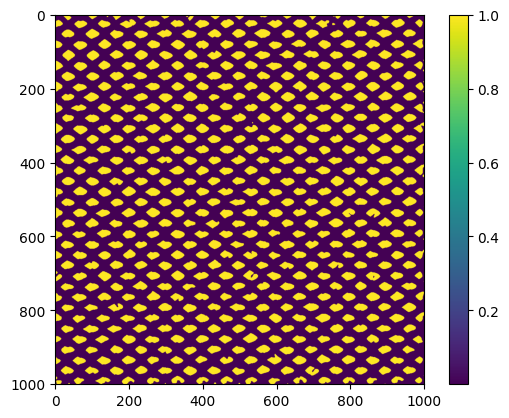

In [38]:
with torch.no_grad():
    costfunctions_test_blob= model_blob(test[:,200:1201,1000:2001], torch.exp(log_σs), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1, torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()
    
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(costfunctions_test_blob[0])
fig.colorbar(cbar, ax=ax)


In [39]:
blobs_test = ((clean_data(costfunctions_test_blob[None])>0.8)*1.)[0]

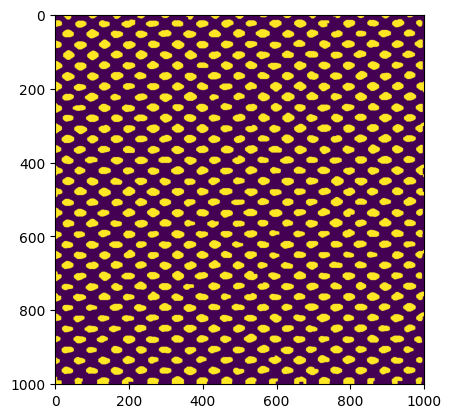

In [40]:
plt.imshow(blobs_test[0])

In [41]:
#torch.save(blobs_test, f"blobs_test_{index}.pt")